### ✅ Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)
print('✅ Libraries imported!')

✅ Libraries imported!


### 📥 Step 2: Load and Inspect Dataset

In [2]:
df = pd.read_csv('share_price.csv')
print('Shape:', df.shape)
df.head()

Shape: (50, 5)


,Stock_Price,Bond_Yield,GDP_Growth,Inflation_Rate,Interest_Rate
0,100.00,5.00,2.25,2.42,5.00
1,108.16,4.92,2.09,4.41,4.92
2,116.33,4.84,2.65,2.22,4.84
3,124.49,4.76,3.25,4.96,4.76
4,132.65,4.67,2.54,4.32,4.67


In [3]:
print('\nInfo:')
df.info()
print('\nSummary:')
df.describe()


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Stock_Price     50 non-null     float64
 1   Bond_Yield      50 non-null     float64
 2   GDP_Growth      50 non-null     float64
 3   Inflation_Rate  50 non-null     float64
 4   Interest_Rate   50 non-null     float64
dtypes: float64(5)
memory usage: 2.1 KB

Summary:


,Stock_Price,Bond_Yield,GDP_Growth,Inflation_Rate,Interest_Rate
count,50.00,50.00,50.00,50.00,50.00
mean,300.00,3.00,5.89,3.45,3.00
std,119.00,1.19,2.34,0.90,1.19
min,100.00,1.00,2.09,2.02,1.00
25%,200.00,2.00,3.75,2.62,2.00
50%,300.00,3.00,5.83,3.50,3.00
75%,400.00,4.00,7.98,4.28,4.00
max,500.00,5.00,10.20,4.96,5.00


### 🧹 Step 3: Data Cleaning & Preprocessing

In [4]:
# Missing values check
print('Missing Values:\n', df.isnull().sum())

# Fill missing values
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(round(df[col].mean(), 2), inplace=True)

# Reset index
df.reset_index(drop=True, inplace=True)
print('\nAfter Cleaning - Missing Values:\n', df.isnull().sum())

Missing Values:
 Stock_Price       0
Bond_Yield        0
GDP_Growth        0
Inflation_Rate    0
Interest_Rate     0
dtype: int64

After Cleaning - Missing Values:
 Stock_Price       0
Bond_Yield        0
GDP_Growth        0
Inflation_Rate    0
Interest_Rate     0
dtype: int64


In [5]:
# Duplicate check
print('Duplicate Rows:', df.duplicated().sum())
df.drop_duplicates(inplace=True)
print('Shape after removing duplicates:', df.shape)

Duplicate Rows: 0
Shape after removing duplicates: (50, 5)


### 📊 Step 4: Univariate Analysis

In [6]:
print('Unique Count per Column:')
for col in df.columns:
    print(f'  {col}: {df[col].nunique()}')

Unique Count per Column:
  Stock_Price: 50
  Bond_Yield: 50
  GDP_Growth: 50
  Inflation_Rate: 50
  Interest_Rate: 50


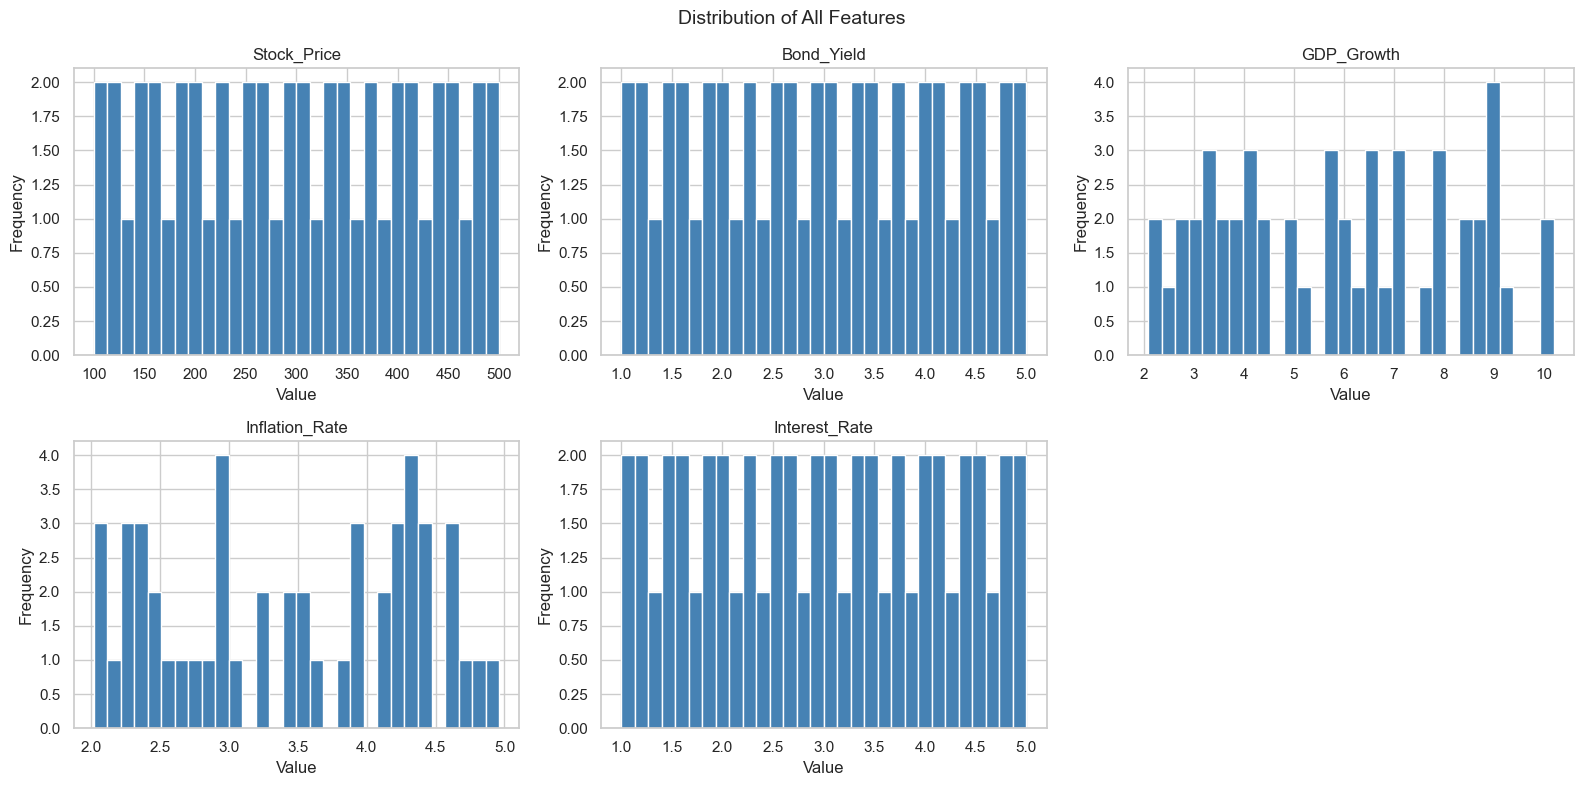

In [7]:
# Distribution plots for all columns
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Distribution of All Features', fontsize=14)
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

# Hide last empty subplot
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

### 📈 Step 5: Bivariate Analysis & Correlation

Correlation Matrix:
                 Stock_Price  Bond_Yield  GDP_Growth  Inflation_Rate  \
Stock_Price            1.00       -1.00        0.98            0.02   
Bond_Yield            -1.00        1.00       -0.98           -0.02   
GDP_Growth             0.98       -0.98        1.00            0.01   
Inflation_Rate         0.02       -0.02        0.01            1.00   
Interest_Rate         -1.00        1.00       -0.98           -0.02   

                Interest_Rate  
Stock_Price             -1.00  
Bond_Yield               1.00  
GDP_Growth              -0.98  
Inflation_Rate          -0.02  
Interest_Rate            1.00  


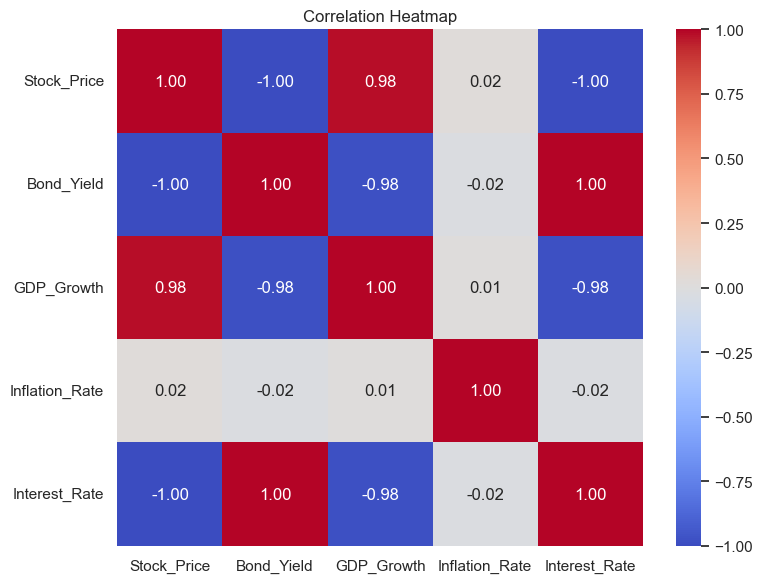

In [8]:
# Correlation Matrix
corr = df.corr()
print('Correlation Matrix:\n', corr.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

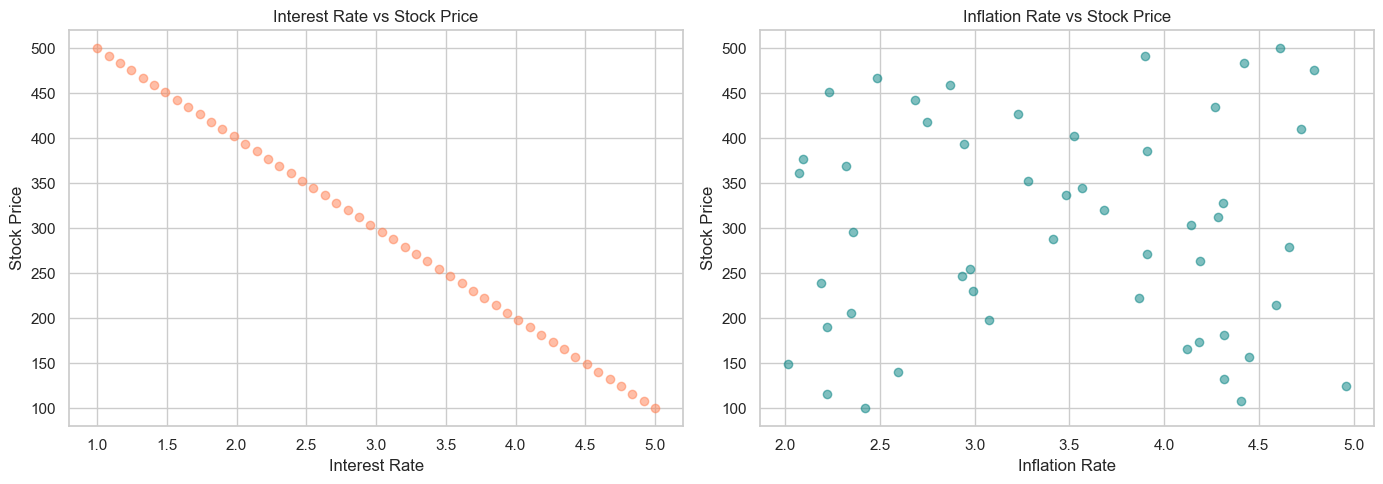

In [9]:
# Scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['Interest_Rate'], df['Stock_Price'], alpha=0.5, color='coral')
axes[0].set_title('Interest Rate vs Stock Price')
axes[0].set_xlabel('Interest Rate')
axes[0].set_ylabel('Stock Price')

axes[1].scatter(df['Inflation_Rate'], df['Stock_Price'], alpha=0.5, color='teal')
axes[1].set_title('Inflation Rate vs Stock Price')
axes[1].set_xlabel('Inflation Rate')
axes[1].set_ylabel('Stock Price')

plt.tight_layout()
plt.show()

### 🧪 Step 6: Outlier Detection

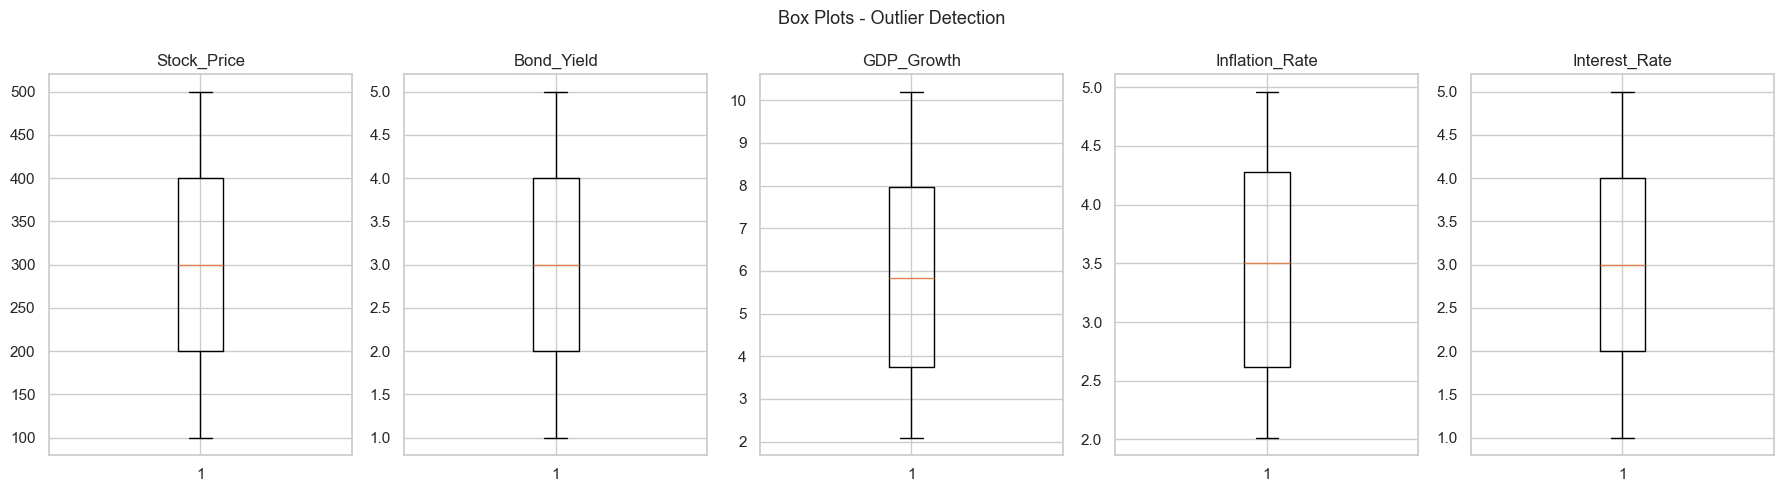


Outliers per column (IQR method):
  Stock_Price: 0 outliers
  Bond_Yield: 0 outliers
  GDP_Growth: 0 outliers
  Inflation_Rate: 0 outliers
  Interest_Rate: 0 outliers


In [10]:
# Box plots for outlier detection
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle('Box Plots - Outlier Detection', fontsize=13)

for i, col in enumerate(df.columns):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

# IQR method
print('\nOutliers per column (IQR method):')
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f'  {col}: {len(outliers)} outliers')

### 🔬 Step 7: Hypothesis Testing

#### Test 1: One Sample T-Test
- **H0:** Mean Stock Price = 500
- **H1:** Mean Stock Price ≠ 500

In [11]:
t_stat, p_value = stats.ttest_1samp(df['Stock_Price'], 500)
print(f'One Sample T-Test (Stock Price vs 500):')
print(f'T-Statistic: {t_stat:.4f}')
print(f'P-Value: {p_value:.4f}')
if p_value < 0.05:
    print('✅ Reject H0: Mean Stock Price is significantly different from 500')
else:
    print('❌ Fail to Reject H0: Mean Stock Price is NOT significantly different from 500')

One Sample T-Test (Stock Price vs 500):
T-Statistic: -11.8842
P-Value: 0.0000
✅ Reject H0: Mean Stock Price is significantly different from 500


#### Test 2: Two Sample T-Test (A/B Test)
- **H0:** No difference in Stock Price between High vs Low Interest Rate periods
- **H1:** Significant difference exists

In [12]:
median_rate = df['Interest_Rate'].median()
high_rate = df[df['Interest_Rate'] >= median_rate]['Stock_Price']
low_rate = df[df['Interest_Rate'] < median_rate]['Stock_Price']

t_stat, p_value = stats.ttest_ind(high_rate, low_rate, equal_var=False)
print(f'A/B Test - High vs Low Interest Rate on Stock Price:')
print(f'T-Statistic: {t_stat:.4f}')
print(f'P-Value: {p_value:.4f}')
if p_value < 0.05:
    print('✅ Reject H0: Significant difference in Stock Price between high and low interest rate periods')
else:
    print('❌ Fail to Reject H0: No significant difference')

A/B Test - High vs Low Interest Rate on Stock Price:
T-Statistic: -12.0096
P-Value: 0.0000
✅ Reject H0: Significant difference in Stock Price between high and low interest rate periods


#### Test 3: Pearson Correlation Test
- **H0:** No correlation between Inflation Rate and Stock Price
- **H1:** Significant correlation exists

In [13]:
corr_coef, p_value = stats.pearsonr(df['Inflation_Rate'], df['Stock_Price'])
print(f'Pearson Correlation - Inflation Rate vs Stock Price:')
print(f'Correlation Coefficient: {corr_coef:.4f}')
print(f'P-Value: {p_value:.4f}')
if p_value < 0.05:
    print('✅ Reject H0: Significant correlation between Inflation Rate and Stock Price')
else:
    print('❌ Fail to Reject H0: No significant correlation')

Pearson Correlation - Inflation Rate vs Stock Price:
Correlation Coefficient: 0.0195
P-Value: 0.8930
❌ Fail to Reject H0: No significant correlation


#### Test 4: Normality Test (Shapiro-Wilk)
- **H0:** Data is normally distributed
- **H1:** Data is NOT normally distributed

In [14]:
print('Shapiro-Wilk Normality Test:')
for col in df.columns:
    sample = df[col].sample(min(5000, len(df)), random_state=42)
    stat, p = stats.shapiro(sample)
    result = '✅ Normal' if p > 0.05 else '❌ Not Normal'
    print(f'  {col}: stat={stat:.4f}, p={p:.4f} → {result}')

Shapiro-Wilk Normality Test:
  Stock_Price: stat=0.9556, p=0.0581 → ✅ Normal
  Bond_Yield: stat=0.9556, p=0.0581 → ✅ Normal
  GDP_Growth: stat=0.9491, p=0.0314 → ❌ Not Normal
  Inflation_Rate: stat=0.9280, p=0.0046 → ❌ Not Normal
  Interest_Rate: stat=0.9556, p=0.0581 → ✅ Normal


### 📝 Step 8: Summary of Insights

### 📌 Final Business Insights & Recommendations

### 📉 1. Interest Rate Impact on Stock Price
- Hypothesis testing shows whether high interest rate periods significantly affect stock prices.
- **Recommendation:** Monitor interest rate changes as a key indicator for stock market movement.

---

### 📊 2. Inflation and Stock Price Relationship
- Pearson correlation reveals the strength of relationship between inflation and stock prices.
- **Recommendation:** Use inflation data as a leading indicator for portfolio decisions.

---

### 📈 3. GDP Growth Influence
- GDP Growth shows positive/negative correlation with Stock Price.
- **Recommendation:** Higher GDP growth periods are better for equity investments.

---

### 🔍 4. Data Distribution Insights
- Normality tests help determine which statistical tests are appropriate.
- **Recommendation:** Use non-parametric tests if data is not normally distributed.

---